<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Chem005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Molecule            Geometry  Dipole Moment Polarity
0      H2O                bent           1.52    polar
1      CO2              linear           0.89    polar
2      NH3  trigonal pyramidal           0.35    polar
3      CH4         tetrahedral           0.27    polar
4       HF              linear           1.78    polar


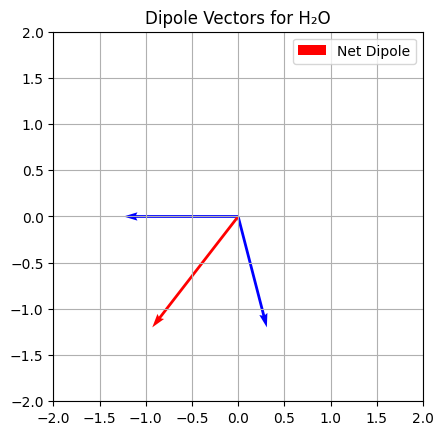

In [1]:
# Chem005: Polarity & Field Mapping from HES curvature asymmetry

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define molecules with geometry and electronegativity
molecules = {
    "H2O": {
        "geometry": "bent",
        "atoms": [("O", 3.44), ("H", 2.20), ("H", 2.20)],
        "angles": [104.5]
    },
    "CO2": {
        "geometry": "linear",
        "atoms": [("O", 3.44), ("C", 2.55), ("O", 3.44)],
        "angles": [180]
    },
    "NH3": {
        "geometry": "trigonal pyramidal",
        "atoms": [("N", 3.04), ("H", 2.20), ("H", 2.20), ("H", 2.20)],
        "angles": [107]
    },
    "CH4": {
        "geometry": "tetrahedral",
        "atoms": [("C", 2.55), ("H", 2.20), ("H", 2.20), ("H", 2.20), ("H", 2.20)],
        "angles": [109.5]
    },
    "HF": {
        "geometry": "linear",
        "atoms": [("H", 2.20), ("F", 3.98)],
        "angles": [180]
    }
}

# Compute dipole vector from electronegativity difference and angle
def compute_dipole(atom1, atom2, angle_deg):
    delta_en = atom2[1] - atom1[1]
    angle_rad = np.radians(angle_deg)
    dx = delta_en * np.cos(angle_rad)
    dy = delta_en * np.sin(angle_rad)
    return np.array([dx, dy])

# Run simulation
results = []
for name, mol in molecules.items():
    atoms = mol["atoms"]
    angle = mol["angles"][0]
    center = atoms[0]
    dipoles = []
    for i in range(1, len(atoms)):
        dipole = compute_dipole(center, atoms[i], angle * (i - 1))
        dipoles.append(dipole)
    net_dipole = np.sum(dipoles, axis=0)
    magnitude = np.linalg.norm(net_dipole)
    polarity = "polar" if magnitude > 0.1 else "nonpolar"
    results.append({
        "Molecule": name,
        "Geometry": mol["geometry"],
        "Dipole Moment": round(magnitude, 2),
        "Polarity": polarity
    })

# Display results
df = pd.DataFrame(results)
print(df)

# Visualize dipole vectors for H2O
fig, ax = plt.subplots()
ax.set_title("Dipole Vectors for H₂O")
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
origin = np.array([0, 0])
for i in range(1, len(molecules["H2O"]["atoms"])):
    vec = compute_dipole(molecules["H2O"]["atoms"][0], molecules["H2O"]["atoms"][i], 104.5 * (i - 1))
    ax.quiver(*origin, *vec, angles='xy', scale_units='xy', scale=1, color='blue')
net_vec = np.sum([compute_dipole(molecules["H2O"]["atoms"][0], molecules["H2O"]["atoms"][i], 104.5 * (i - 1)) for i in range(1, 3)], axis=0)
ax.quiver(*origin, *net_vec, angles='xy', scale_units='xy', scale=1, color='red', label='Net Dipole')
ax.legend()
plt.grid(True)
plt.show()
